Loading Chua dataset...
Dataset loaded: (100000, 3) samples.
Creating sliding windows...
Input Shape: (99950, 50, 3), Target Shape: (99950, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 50, 64)              │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 25, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 25, 32)              │           6,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 32)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,971 (31.14 KB)

 Trainable params: 7,971 (31.14 KB)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0149 - val_loss: 2.7764e-04
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 1.5646e-04 - val_loss: 1.7155e-04
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 1.0534e-04 - val_loss: 6.1610e-05
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 8.4462e-05 - val_loss: 7.6314e-05
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 5.8971e-05 - val_loss: 5.1458e-05
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 6.7159e-05 - val_loss: 1.4053e-04
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 5.5614e-05 - val_loss: 1.7931e-05
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 4.8653e-05 - val_loss: 1.6376e-04
Epoch 9/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 4.9522e-05 - val_loss: 3.7495e-05
Epoch 10/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 5.7251e-05 - val_loss: 1.9437e-05
Epoch 11/20
1250/125


Model saved as 'chua_cnn_model.h5'

Running Generative Loop (Autoregressive)...


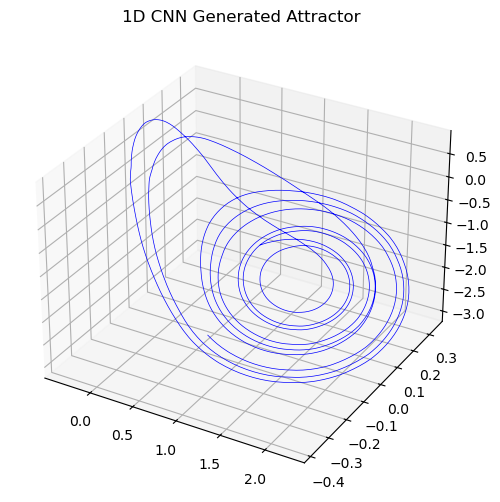

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt
import time

# --- 1. Configuration ---
WINDOW_SIZE = 50   # How many past steps the CNN sees
PREDICT_HORIZON = 1 # Predict 1 step ahead
BATCH_SIZE = 64
EPOCHS = 20

# --- 2. Load Chua Dataset ---
print("Loading Chua dataset...")
# Assuming you have the same .npy files from your ESN project
try:
    data = np.load("chua_3d_inputs.npy") # Shape (N, 3)
    print(f"Dataset loaded: {data.shape} samples.")
except FileNotFoundError:
    print("Error: chua_3d_inputs.npy not found. Please run the data generation script.")
    exit()

# Normalize Data (Crucial for CNNs)
data_mean = data.mean(axis=0)
data_std = data.std(axis=0)
data_norm = (data - data_mean) / data_std

# --- 3. Prepare Sliding Windows (X -> y) ---
# X: Sequence of 50 steps, y: Next step
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back)])
        Y.append(dataset[i + look_back])
    return np.array(X), np.array(Y)

print("Creating sliding windows...")
X, y = create_dataset(data_norm, WINDOW_SIZE)
print(f"Input Shape: {X.shape}, Target Shape: {y.shape}")

# Split Train/Val
split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

# --- 4. Build 1D CNN Model ---
# Architecture:
# [Conv1D] -> [Relu] -> [MaxPooling] -> [Conv1D] -> [GlobalPool] -> [Dense]
model = models.Sequential([
    layers.Input(shape=(WINDOW_SIZE, 3)), # 3 channels for x, y, z
    
    # Layer 1: Feature Extraction
    layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    
    # Layer 2: Deeper Features
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    
    # Flatten & Readout
    layers.GlobalAveragePooling1D(), # Efficient dimensionality reduction
    layers.Dense(32, activation='relu'),
    layers.Dense(3) # Output: predicted x, y, z
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# --- 5. Train ---
print("\nStarting Training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# --- 6. Save Model ---
model.save("chua_cnn_model.h5")
print("\nModel saved as 'chua_cnn_model.h5'")

# --- 7. Validation: Autoregressive Generation ---
# Let's verify if it actually learned chaos or just memorized.
print("\nRunning Generative Loop (Autoregressive)...")
generated = []
# Start with a real seed from validation set
current_window = X_val[0].reshape(1, WINDOW_SIZE, 3)

for _ in range(2000):
    # Predict next step
    next_step = model.predict(current_window, verbose=0)
    generated.append(next_step[0])
    
    # Update window: Shift left, append prediction
    next_step_reshaped = next_step.reshape(1, 1, 3)
    current_window = np.concatenate([current_window[:, 1:, :], next_step_reshaped], axis=1)

# Denormalize
generated = np.array(generated) * data_std + data_mean

# Plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(generated[:,0], generated[:,1], generated[:,2], lw=0.5, c='blue')
ax.set_title("1D CNN Generated Attractor")
plt.show()

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
import matplotlib.pyplot as plt

# --- 1. Load Model & Setup Feature Extractor ---
print("Loading CNN model...")
model = load_model("chua_cnn_model.h5", compile=False)

# We want to tap into the internal layers to get high entropy
# Let's get the output of the "GlobalAveragePooling1D" layer (before the final Dense)
# This gives us a rich feature vector (size 32 in our architecture)
extractor_model = Model(inputs=model.inputs, outputs=model.layers[-2].output) 

# --- 2. Helper Functions (ARX Mixer & XOR Chain) ---
def rotate_left(val, r_bits, bit_width=32):
    return ((val << r_bits) & (2**bit_width - 1)) | (val >> (bit_width - r_bits))

def arx_mix(v0, v1):
    sum_val = (v0 + v1) & 0xFFFFFFFF
    rot_val = rotate_left(sum_val, 7)
    xor_val = rot_val ^ v0
    return xor_val

# --- 3. Run Generative Loop with Tapping ---
print("Generating Secure Stream...")
N_BITS_NEEDED = 1280000 # 1 Million bits for testing
BATCH_SIZE_GEN = 1000
generated_bits = []

# Initialize Window (Seed)
current_window = np.random.randn(1, 50, 3) 

while len(generated_bits) * 32 < N_BITS_NEEDED:
    # 1. Get Prediction & Internal Features
    # Note: We run both the full model (for next step) and extractor (for entropy)
    next_val = model.predict(current_window, verbose=0)
    features = extractor_model.predict(current_window, verbose=0)[0] # Shape (32,)
    
    # 2. Update Window (Autoregressive step)
    next_val_reshaped = next_val.reshape(1, 1, 3)
    current_window = np.concatenate([current_window[:, 1:, :], next_val_reshaped], axis=1)

    # --- 3. ENTROPY EXTRACTION (The "Magic") ---
    # We treat the 32 internal features as our "Reservoir State"
    # Convert floats to 32-bit integers
    features_int = (features * 1e9).astype(np.int32) & 0xFFFFFFFF
    
    # 4. ARX Mixing (Mix the features together)
    mixed_val = 0
    for i in range(0, 32, 2):
        mixed_val = arx_mix(mixed_val, features_int[i])
        
    # 5. Path B: Skew Tent Map (STM) using the output 'x' value
    # Normalize model output x to [0, 1]
    stm_input = (next_val[0, 0] - (-20)) / (20 - (-20)) # Approx range -20 to 20
    stm_input = np.clip(stm_input, 0.01, 0.99)
    
    # Run STM equation
    P_STM = 0.6
    if stm_input < P_STM:
        stm_out = stm_input / P_STM
    else:
        stm_out = (1 - stm_input) / (1 - P_STM)
        
    stm_int = int(stm_out * (2**32)) & 0xFFFFFFFF
    
    # 6. Final XOR (CNN Features XOR STM)
    final_32bit = mixed_val ^ stm_int
    generated_bits.append(final_32bit)

    if len(generated_bits) % 1000 == 0:
        print(f"Generated {len(generated_bits)} blocks...")

# --- 4. Save to Binary File ---
print("Saving to binary file...")
final_array = np.array(generated_bits, dtype=np.uint32)
final_array.tofile("cnn_csprng_output.bin")
print(f"Saved {len(final_array)*32} bits to cnn_csprng_output.bin")

Loading CNN model...
Generating Secure Stream...


C:\Users\tarit\AppData\Local\Temp\ipykernel_27776\859137843.py:47: RuntimeWarning: invalid value encountered in cast
  features_int = (features * 1e9).astype(np.int32) & 0xFFFFFFFF


Generated 1000 blocks...
Generated 2000 blocks...
Generated 3000 blocks...
Generated 4000 blocks...
Generated 5000 blocks...
Generated 6000 blocks...
Generated 7000 blocks...
Generated 8000 blocks...
Generated 9000 blocks...
Generated 10000 blocks...
Generated 11000 blocks...
Generated 12000 blocks...
Generated 13000 blocks...
Generated 14000 blocks...
Generated 15000 blocks...
Generated 16000 blocks...
Generated 17000 blocks...
Generated 18000 blocks...
Generated 19000 blocks...
Generated 20000 blocks...
Generated 21000 blocks...
Generated 22000 blocks...
Generated 23000 blocks...
Generated 24000 blocks...
Generated 25000 blocks...
Generated 26000 blocks...
Generated 27000 blocks...
Generated 28000 blocks...
Generated 29000 blocks...
Generated 30000 blocks...
Generated 31000 blocks...
Generated 32000 blocks...
Generated 33000 blocks...
Generated 34000 blocks...
Generated 35000 blocks...
Generated 36000 blocks...
Generated 37000 blocks...
Generated 38000 blocks...
Generated 39000 block

In [5]:
# Save this as extract_weights.py and run on PC
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

# 1. Load the trained Keras model
print("Loading model...")
model = load_model("chua_cnn_model.h5", compile=False)

# 2. Extract Weights layer by layer
# Architecture recap:
# Layer 0: Conv1D (64 filters, kernel 3)
# Layer 1: MaxPooling (No weights)
# Layer 2: Conv1D (32 filters, kernel 3)
# Layer 3: GlobalAvgPool (No weights)
# Layer 4: Dense (32 units)
# Layer 5: Dense (3 units)

weights_dict = {}

# Conv Layer 1
w, b = model.layers[0].get_weights()
weights_dict['c1_w'] = w  # Shape: (3, 3, 64)
weights_dict['c1_b'] = b  # Shape: (64,)

# Conv Layer 2 (Index 2 because Index 1 is Pooling)
w, b = model.layers[2].get_weights()
weights_dict['c2_w'] = w  # Shape: (3, 64, 32)
weights_dict['c2_b'] = b  # Shape: (32,)

# Dense Layer 1 (Index 4)
w, b = model.layers[4].get_weights()
weights_dict['d1_w'] = w
weights_dict['d1_b'] = b

# Dense Layer 2 (Index 5)
w, b = model.layers[5].get_weights()
weights_dict['d2_w'] = w
weights_dict['d2_b'] = b

# 3. Save to file
print("Saving weights to 'cnn_weights.npz'...")
np.savez("cnn_weights.npz", **weights_dict)
print("Done. Transfer 'cnn_weights.npz' to your PYNQ board.")

Loading model...
Saving weights to 'cnn_weights.npz'...
Done. Transfer 'cnn_weights.npz' to your PYNQ board.
